# 前向欧拉法求解一维简谐振子

- [周详](xiangzhou@whu.edu.cn)
- 武汉大学 
- 2026年9月13日

2026年9月13日

一维简谐振子满足 $m\ddot{x} = -kx$。取 $k = 1$、$m = 1$（$\omega = \sqrt{k/m} = 1$），化为一阶方程组：

$$
\frac{dx}{dt} = v, \qquad \frac{dv}{dt} = -\frac{k}{m}\,x = -x
$$

初始条件 $x_0 = 1$、$v_0 = 0$，解析解为

$$
x(t) = x_0\cos(\omega t) + \frac{v_0}{\omega}\sin(\omega t) = \cos t, \qquad v(t) = -\sin t
$$

**总能量** $E = \tfrac{1}{2}mv^2 + \tfrac{1}{2}kx^2$ 严格守恒，解析解在速度相空间 $(x, v)$ 中沿半径为 $1$ 的圆运动。

**前向欧拉法（Forward Euler）** 的离散格式：

$$
x_{n+1} = x_n + h\,v_n, \qquad v_{n+1} = v_n - h\,\omega^2 x_n
$$

**运行之前，先把你的预测写下来**：

1. 总能量在数值解中还守恒吗？把更新格式代入 $E_{n+1} = \tfrac{1}{2}m\,v_{n+1}^2 + \tfrac{1}{2}k\,x_{n+1}^2$，算出比值 $E_{n+1}/E_n$——它是常数还是依赖当前状态？由此判断 $E_n$ 随 $n$ 增长的"形状"。
2. 速度相空间 $(x, v)$ 中，数值轨迹相对解析圆周会如何演化？
3. 与第 2 册自由落体的线性漂移相比，这里的漂移会更快还是更慢？为什么？

带着预测运行下面的代码，逐条对照。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 字体配置：按操作系统自动选择中文字体，
# 西文与数学公式用 Times New Roman 风格（STIX）
import platform
system = platform.system()
if system == 'Darwin':
    cn_font = 'Songti SC'
elif system == 'Windows':
    cn_font = 'SimSun'
else:  # Linux
    cn_font = 'Noto Serif CJK SC'

plt.rcParams['font.family'] = [cn_font, 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def forward_euler_oscillator(x0, v0, k, m, h, n_steps):
    """前向欧拉法求解简谐振子 dx/dt = v, dv/dt = -(k/m) x
    返回时间、位置、速度数组（长度 n_steps + 1）"""
    omega2 = k / m
    t = np.arange(n_steps + 1) * h
    x = np.empty(n_steps + 1)
    v = np.empty(n_steps + 1)
    x[0], v[0] = x0, v0
    for n in range(n_steps):
        x[n + 1] = x[n] + h * v[n]
        v[n + 1] = v[n] - h * omega2 * x[n]
    return t, x, v

初始能量 E0 = 0.5000 J（守恒值）
末时刻数值能量 = 9.8942 J
能量放大倍数 = 19.79，振幅放大 = 4.45


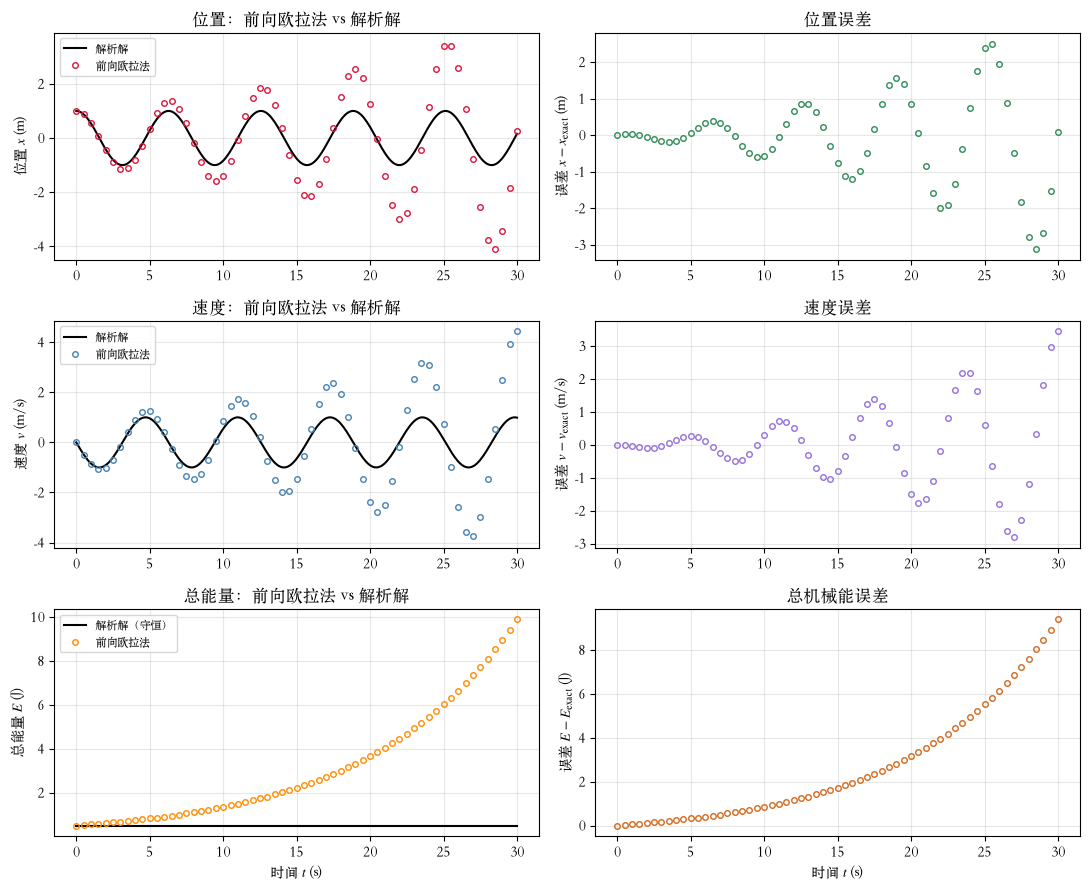

In [3]:
# 参数
x0, v0 = 1.0, 0.0   # 初始位置 (m)、初速度 (m/s)
k, m = 1.0, 1.0     # 劲度系数 (N/m)、质量 (kg)，omega = 1
h = 0.1             # 时间步长 (s)
t_end = 30.0        # 总时间 (s)，约 4.8 个周期

t, x, v = forward_euler_oscillator(x0, v0, k, m, h, int(t_end / h))
omega = np.sqrt(k / m)
x_exact = x0 * np.cos(omega * t) + (v0 / omega) * np.sin(omega * t)
v_exact = -x0 * omega * np.sin(omega * t) + v0 * np.cos(omega * t)
E = 0.5 * m * v**2 + 0.5 * k * x**2
E_exact = 0.5 * m * v_exact**2 + 0.5 * k * x_exact**2

# 位置误差（带符号）：解析解为 cos(t) 会过零，相对误差无定义，故用绝对误差
err_x = x - x_exact
err_v = v - v_exact
E_err = E - E_exact[0]

print(f'初始能量 E0 = {E[0]:.4f} J（守恒值）')
print(f'末时刻数值能量 = {E[-1]:.4f} J')
print(f'能量放大倍数 = {E[-1] / E[0]:.2f}，振幅放大 = {np.sqrt(E[-1] / E[0]):.2f}')

fig, axs = plt.subplots(3, 2, figsize=(11, 9))

# 左列：数值解 vs 解析解
ax = axs[0, 0]
ax.plot(t, x_exact, 'k-', lw=1.5, label='解析解')
ax.plot(t, x, 'o', ms=4, mfc='none', color='crimson', label='前向欧拉法', markevery=5)
ax.set_ylabel('位置 $x$ (m)')
ax.set_title('位置：前向欧拉法 vs 解析解')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

ax = axs[1, 0]
ax.plot(t, v_exact, 'k-', lw=1.5, label='解析解')
ax.plot(t, v, 'o', ms=4, mfc='none', color='steelblue', label='前向欧拉法', markevery=5)
ax.set_ylabel('速度 $v$ (m/s)')
ax.set_title('速度：前向欧拉法 vs 解析解')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

ax = axs[2, 0]
ax.plot(t, E_exact, 'k-', lw=1.5, label='解析解（守恒）')
ax.plot(t, E, 'o', ms=4, mfc='none', color='darkorange', label='前向欧拉法', markevery=5)
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('总能量 $E$ (J)')
ax.set_title('总能量：前向欧拉法 vs 解析解')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# 右列：对应的误差
ax = axs[0, 1]
ax.plot(t, err_x, 'o', ms=4, mfc='none', color='seagreen', markevery=5)
ax.set_ylabel('误差 $x - x_{\\mathrm{exact}}$ (m)')
ax.set_title('位置误差')
ax.grid(alpha=0.3)

ax = axs[1, 1]
ax.plot(t, err_v, 'o', ms=4, mfc='none', color='mediumpurple', markevery=5)
ax.set_ylabel('误差 $v - v_{\\mathrm{exact}}$ (m/s)')
ax.set_title('速度误差')
ax.grid(alpha=0.3)

ax = axs[2, 1]
ax.plot(t, E_err, 'o', ms=4, mfc='none', color='chocolate', markevery=5)
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('误差 $E - E_{\\mathrm{exact}}$ (J)')
ax.set_title('总机械能误差')
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('outputs/3_simple_oscillator_euler_main.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

**检验你的预测**：数值能量随 $t$ 如何增长——线性、指数，还是别的？作 $\ln E$–$t$ 图验证；再把更新格式代入 $E_{n+1}$ 推导每步能量比 $E_{n+1}/E_n$，并与第 2 册的每步恒量增量对比。

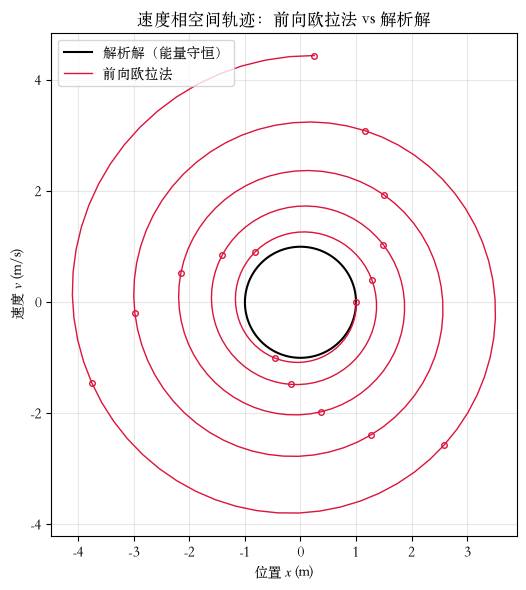

In [4]:
# 速度相空间轨迹：解析解 vs 前向欧拉法
theta = np.linspace(0, 2 * np.pi, 200)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(np.cos(theta), np.sin(theta), 'k-', lw=1.5, label='解析解（能量守恒）')
ax.plot(x, v, '-', lw=1, color='crimson', label='前向欧拉法')
ax.plot(x[::20], v[::20], 'o', ms=4, mfc='none', color='crimson')
ax.set_xlabel('位置 $x$ (m)')
ax.set_ylabel('速度 $v$ (m/s)')
ax.set_title('速度相空间轨迹：前向欧拉法 vs 解析解')
ax.set_aspect('equal')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('outputs/3_simple_oscillator_euler_phase.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

## 速度相空间矢量场

简谐振子在速度相空间 $(x, v)$ 中的运动由线性矢量场

$$
\frac{dx}{dt} = v, \qquad \frac{dv}{dt} = -\frac{k}{m}x
$$

决定：每一点处的箭头给出系统经过该状态时的运动方向。图中箭头已归一化为单位长度（只显示方向），颜色表示归一化速率。

几个要点：

- **唯一平衡点** $(0, 0)$：中心（稳定），附近矢量场呈涡旋状。线性系统没有鞍点——这与大振幅单摆不同（非线性引入了 $\pm\pi$ 处的不稳定平衡）。
- **所有轨道均为闭合椭圆**（此处 $\omega = 1$，退化为圆）：等能线 $\tfrac{1}{2}mv^2 + \tfrac{1}{2}kx^2 = E$ 是一族同心圆，周期与振幅无关（简谐振子的等时性）。
- 矢量场处处与等能线相切，故真实解沿闭合轨道运动（能量守恒）；而前向欧拉解不断穿越等能线向外螺旋（见上图）。

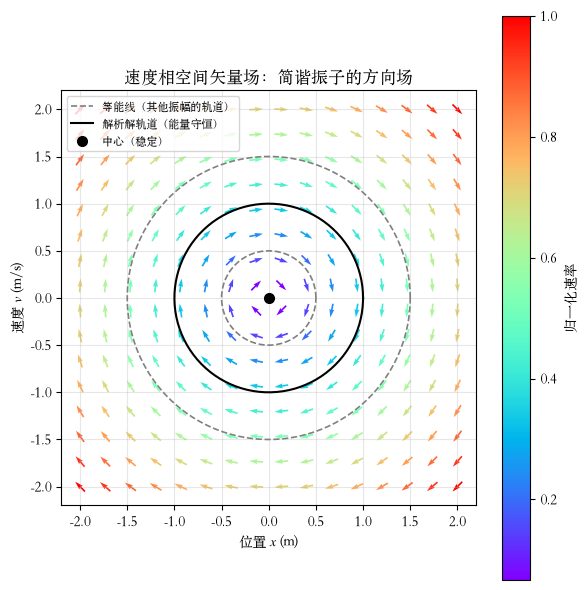

In [5]:
# 速度相空间矢量场：(dx/dt, dv/dt) = (v, -(k/m) x)
# 箭头归一化为单位长度（只表示方向），颜色表示归一化速率
# 矢量场处处与圆轨道（等能线）相切，故解析解能量守恒；
# 而前向欧拉解不断穿越等能线向外螺旋（见上图）
x_grid = np.linspace(-2.0, 2.0, 16)
v_grid = np.linspace(-2.0, 2.0, 16)
X, V = np.meshgrid(x_grid, v_grid)

U, W = V, -(k / m) * X
speed = np.sqrt(U**2 + W**2)
speed_norm = speed / speed.max()

fig, ax = plt.subplots(figsize=(6, 6))
q = ax.quiver(X, V, U / speed, W / speed, speed_norm, cmap='rainbow',
              pivot='mid', scale=30, width=0.004)
cbar = fig.colorbar(q, ax=ax)
cbar.set_label('归一化速率')

# 等能线：同心圆（此处 ω = 1），矢量场处处与之相切
circ = np.linspace(0, 2 * np.pi, 200)
for r in (0.5, 1.5):
    ax.plot(r * np.cos(circ), r * np.sin(circ), '--', color='gray', lw=1.2,
            label='等能线（其他振幅的轨道）' if r == 0.5 else None)

# 解析解轨道：单位圆（本算例初始条件对应的等能线）
ax.plot(np.cos(circ), np.sin(circ), 'k-', lw=1.5, label='解析解轨道（能量守恒）')

# 唯一平衡点：中心 (0, 0)，稳定（线性系统无鞍点，与单摆不同）
ax.plot(0, 0, 'o', color='black', ms=7, zorder=5, label='中心（稳定）')

ax.set_xlabel('位置 $x$ (m)')
ax.set_ylabel('速度 $v$ (m/s)')
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.set_aspect('equal')
ax.set_title('速度相空间矢量场：简谐振子的方向场')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig('outputs/3_simple_oscillator_euler_field.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

### 箭头的位置与颜色约定

- **位置**：每个箭头按 `pivot='mid'` 绘制——箭杆的**中点**恰落在它所描述的速度相空间格点 $(x_i,\,v_i)$ 上，并沿该点处的流方向对称延伸。读图时以箭杆中点为准。
- **颜色**：箭杆归一化为单位长度（只表示方向），矢量的**模长**改用颜色编码：按 $|(\dot x, \dot v)|\,/\,|(\dot x, \dot v)|_{\max}$ 以 rainbow 色条从蓝（慢）到红（快）着色。本例 $(\dot x, \dot v) = (v,\,-\omega_0^2 x)$，模长 $=\sqrt{v^2+\omega_0^4 x^2}$，故离平衡点越远相流越快（越红），平衡点附近最慢（蓝）。

方向（箭头指向）+ 模长（颜色）合在一起，完整给出矢量场的信息。

## 结论与思考

**先对照运行结果，回答引言中的三个预测**（能量是否守恒、按什么形状增长？数值轨迹在速度相空间中如何演化？与自由落体有何不同？）

**值得注意的对比**：与自由落体的**线性**漂移不同，振子的能量按每步恒定的**比例**增长——误差随时间"滚雪球"，越漂越快，速度相空间中数值轨迹螺旋外扩。模拟末时刻（$t = 30$ s）能量已放大约 $20$ 倍。

**为什么减小步长不能根治**：步长减半，每步能量的增长比例更接近 $1$，漂移放慢；但只要时间足够长，能量仍会显著偏离。这是更新格式的**结构性缺陷**——减小步长只能延缓，不能根除。